Success! Found logo using 55 landmarks.


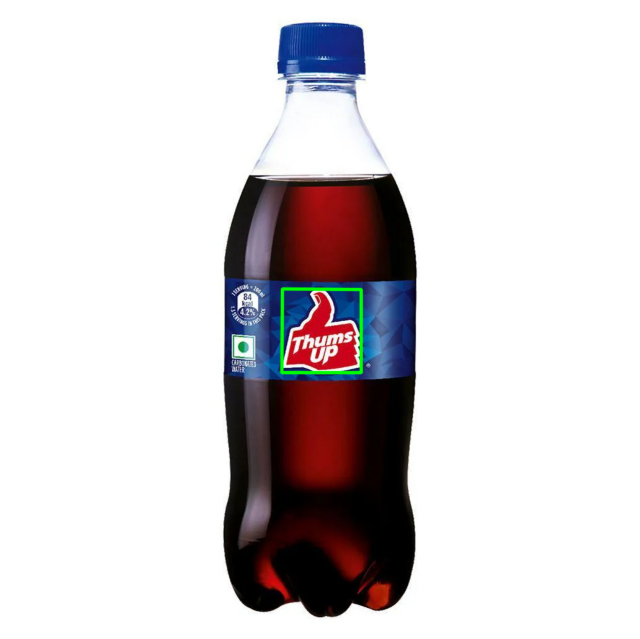

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the images
img_target = cv2.imread('logo_match_input.png')
img_template = cv2.imread('logo_match_temp.png')

# 2. AUTO-CROP THE TEMPLATE (Remove the extra blue background)
# Convert template to HSV to easily isolate the red/white logo from the dark blue
hsv_temp = cv2.cvtColor(img_template, cv2.COLOR_BGR2HSV)
# Mask for the red and white parts of the logo
mask_logo = cv2.threshold(cv2.cvtColor(img_template, cv2.COLOR_BGR2GRAY), 200, 255, cv2.THRESH_BINARY)[1]
mask_red = cv2.inRange(hsv_temp, (0, 100, 100), (10, 255, 255))
combined_mask = cv2.bitwise_or(mask_logo, mask_red)

# Find the bounding box of the actual logo inside the template
coords = cv2.findNonZero(combined_mask)
tx, ty, tw, th = cv2.boundingRect(coords)
# Crop the template to just the logo
cropped_template = img_template[ty:ty+th, tx:tx+tw]
gray_template = cv2.cvtColor(cropped_template, cv2.COLOR_BGR2GRAY)

# 3. SIFT Setup
gray_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp_temp, des_temp = sift.detectAndCompute(gray_template, None)
kp_target, des_target = sift.detectAndCompute(gray_target, None)

# 4. Matching and RANSAC
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
matches = flann.knnMatch(des_temp, des_target, k=2)

good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]

if len(good_matches) >= 4:
    src_pts = np.float32([kp_temp[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_target[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # RANSAC filter to get the exact location
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if M is not None:
        h, w = gray_template.shape
        pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
        dst = cv2.perspectiveTransform(pts, M)

        # Draw the box
        cv2.polylines(img_target, [np.int32(dst)], True, (0, 255, 0), 4, cv2.LINE_AA)
        print(f"Success! Found logo using {len(good_matches)} landmarks.")
    else:
        print("Perspective transform failed.")
else:
    print(f"Not enough landmarks: {len(good_matches)}")

# 5. Show result
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()